# Model 1A: Grid-Searched Logistic Regression

This notebook selects and evaluates a logistic-regression classifier for flights departing John F. Kennedy International Airport (JFK). The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

The model uses the same compact subset of raw pre-departure fields, missing-row rule, stratified 2019 train/test split, random seed, evaluation metrics, and 0.5 threshold as `_01`. `GridSearchCV` selects regularization strength, solver, and class weighting using training data only; the held-out test set is evaluated once after selection. No engineered features, resampling, interaction terms, or probability-threshold tuning are used.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load the 2019 model-assembly data

The path lookup allows the notebook to run from either the capstone directory or the `models` subdirectory.

In [2]:
def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing the expected 2019 model file."""
    for candidate in (start, *start.parents):
        if (candidate / "data/models/JFK_2019_m1a.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/models/JFK_2019_m1a.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data/models/JFK_2019_m1a.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Data source: {DATA_PATH}")
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Data source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/models/JFK_2019_m1a.csv
Rows: 124,759; columns: 71


In [3]:
TARGET = "DepDel15"

target_summary = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .to_frame("flights")
)
target_summary["share"] = target_summary["flights"] / len(df)
target_summary

,flights,share
DepDel15,,
0.0000,101213,0.8113
1.0000,23546,0.1887


## Select raw predictors available before departure

The feature set covers four information groups:

1. **Calendar and schedule:** month, weekday, scheduled departure/arrival times, scheduled elapsed time, and distance.
2. **Flight identity:** reporting airline and destination.
3. **Planned airport demand:** scheduled arrivals and departures during the previous, current, and next clock hours.
4. **Observed weather:** raw temperature, precipitation, humidity, visibility, and wind-speed measurements available by scheduled departure.

Categorical values are one-hot encoded and numeric values are standardized inside the scikit-learn pipeline. These are preprocessing operations, not additional engineered predictors.

Actual departure, taxi, takeoff, and arrival fields are excluded because they would leak the outcome. Identifiers, join-audit timestamps, constants, redundant representations, and existing derived fields such as `WindX`, `WindY`, and `PrecipOccurred` are also excluded.

In [4]:
# Month and weekday are categories rather than continuous measurements.
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]

# Raw schedule, planned-traffic, and weather measurements are scaled numerically.
numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]

feature_columns = categorical_features + numeric_features
required_columns = [TARGET, *feature_columns]
missing_columns = sorted(set(required_columns) - set(df.columns))
assert not missing_columns, f"Required columns are missing: {missing_columns}"

print(f"Selected {len(feature_columns)} raw predictors:")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")

Selected 20 raw predictors:
  categorical: 4
  numeric: 16


## Handle missing values

A few flights at the end of December have missing next-hour ASPM values because their next clock-hour lookup falls in the 2020 ASPM file, while this model-assembly file contains 2019 data. For this initial baseline, those rows are dropped because:

- the number of affected rows is negligible;
- missing planned traffic should not be interpreted as zero traffic; and
- simple removal keeps the first-pass pipeline transparent.

A later data-preparation revision could join the first required ASPM hour from the following year instead.

In [5]:
model_df = df[required_columns].copy()

# Report missingness before removal so the exclusion is visible and auditable.
missing_summary = model_df.isna().sum()
display(missing_summary[missing_summary.gt(0)].to_frame("missing_rows"))

rows_before_drop = len(model_df)
model_df = model_df.dropna(subset=required_columns).copy()
model_df[TARGET] = model_df[TARGET].astype(int)
rows_dropped = rows_before_drop - len(model_df)

print(f"Dropped rows: {rows_dropped:,}")
print(f"Rows retained: {len(model_df):,} ({len(model_df) / rows_before_drop:.3%})")
assert not model_df[required_columns].isna().any().any()

,missing_rows
ASPM_NEXT_SCHEDULED_DEPARTURES,3
ASPM_NEXT_SCHEDULED_ARRIVALS,3


Dropped rows: 3
Rows retained: 124,756 (99.998%)


## Create a stratified train/test split

Only the 2019 data is used in this pass. A reproducible 80/20 random split is stratified on `DepDel15`, preserving approximately the same delayed-flight rate in both partitions. All preprocessing is learned from the training partition inside the pipeline, preventing test-set information from influencing encoding or scaling.

The 2023 and 2024 datasets remain completely unused.

In [6]:
X = model_df[feature_columns]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "delayed_flights": [y_train.sum(), y_test.sum()],
        "delay_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
split_summary

,rows,delayed_flights,delay_rate
train,99804,18837,0.1887
test,24952,4709,0.1887


## Build and search the scikit-learn pipeline

The `ColumnTransformer` applies one-hot encoding to categorical fields and standard scaling to numeric fields within every cross-validation fold. Logistic regression then estimates the probability of a departure delay of at least 15 minutes.

The grid evaluates 24 compatible L2-regularized configurations:

- `C`: 0.001, 0.01, 0.1, 1, 10, or 100. Smaller values impose stronger L2 regularization.
- `solver`: `lbfgs` or `liblinear`, both compatible with L2 regularization and binary classification.
- `class_weight`: equal row weights or scikit-learn's inverse-frequency balanced weights.

Five-fold stratified cross-validation scores each configuration using average precision, ROC AUC, balanced accuracy, recall, and F1. Average precision is the refit metric because delayed flights are the minority class and it evaluates ranking without choosing a new probability threshold. A majority-class dummy classifier remains only as a no-skill evaluation reference.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        ("numeric", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

parameter_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "recall": "recall",
        "f1": "f1",
    },
    refit="average_precision",
    cv=cross_validation,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

dummy_model = DummyClassifier(strategy="prior")

print(f"Hyperparameter combinations: {len(list(ParameterGrid(parameter_grid))):,}")
print(f"Cross-validation fits: {len(list(ParameterGrid(parameter_grid))) * cross_validation.get_n_splits():,}")

Hyperparameter combinations: 24
Cross-validation fits: 120


In [8]:
# Search and refit using training rows only. The test set remains untouched.
grid_search.fit(X_train, y_train)
dummy_model.fit(X_train, y_train)

best_logistic_pipeline = grid_search.best_estimator_

print("Best hyperparameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())
print(f"Best mean cross-validated average precision: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_recall",
    "mean_test_f1",
    "param_classifier__C",
    "param_classifier__solver",
    "param_classifier__class_weight",
]

cv_results.sort_values("rank_test_average_precision")[result_columns].head(10)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best hyperparameters:


,value
classifier__C,0.1000
classifier__class_weight,None
classifier__solver,liblinear


Best mean cross-validated average precision: 0.3573


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_recall,mean_test_f1,param_classifier__C,param_classifier__solver,param_classifier__class_weight
9,1,0.3573,0.0071,0.6940,0.5129,0.0307,0.0584,0.1000,liblinear,None
13,2,0.3572,0.0070,0.6940,0.5134,0.0321,0.0608,1.0000,liblinear,None
8,3,0.3572,0.0070,0.6940,0.5130,0.0308,0.0586,0.1000,lbfgs,None
17,4,0.3571,0.0070,0.6940,0.5135,0.0323,0.0613,10.0000,liblinear,None
21,5,0.3571,0.0070,0.6939,0.5135,0.0324,0.0614,100.0000,liblinear,None
16,6,0.3570,0.0070,0.6939,0.5136,0.0325,0.0616,10.0000,lbfgs,None
12,7,0.3570,0.0070,0.6940,0.5134,0.0321,0.0608,1.0000,lbfgs,None
20,8,0.3570,0.0070,0.6940,0.5137,0.0328,0.0620,100.0000,lbfgs,None
4,9,0.3565,0.0070,0.6932,0.5089,0.0209,0.0404,0.0100,lbfgs,None
5,10,0.3564,0.0070,0.6930,0.5089,0.0210,0.0406,0.0100,liblinear,None


## Evaluate the held-out test set

The grid-selected estimator is now evaluated once on the untouched test partition. Accuracy is reported but is not sufficient because delayed flights are the minority class. Balanced accuracy, precision, recall, F1, ROC AUC, and average precision provide complementary views of performance.

In [9]:
def evaluate_classifier(model, X_values, y_values, model_name, partition):
    """Return threshold and ranking metrics for one fitted classifier."""
    predictions = model.predict(X_values)
    probabilities = model.predict_proba(X_values)[:, 1]
    return {
        "partition": partition,
        "model": model_name,
        "accuracy": accuracy_score(y_values, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_values, predictions),
        "precision": precision_score(y_values, predictions, zero_division=0),
        "recall": recall_score(y_values, predictions, zero_division=0),
        "f1": f1_score(y_values, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_values, probabilities),
        "average_precision": average_precision_score(y_values, probabilities),
    }


evaluation_results = pd.DataFrame(
    [
        evaluate_classifier(dummy_model, X_test, y_test, "Dummy (class prior)", "test"),
        evaluate_classifier(best_logistic_pipeline, X_train, y_train, "Grid-searched logistic regression", "train"),
        evaluate_classifier(best_logistic_pipeline, X_test, y_test, "Grid-searched logistic regression", "test"),
    ]
).set_index(["partition", "model"])

evaluation_results

,,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
partition,model,,,,,,,
test,Dummy (class prior),0.8113,0.5000,0.0000,0.0000,0.0000,0.5000,0.1887
train,Grid-searched logistic regression,0.8134,0.5133,0.6087,0.0314,0.0597,0.6964,0.3601
test,Grid-searched logistic regression,0.8124,0.5123,0.5521,0.0304,0.0576,0.6996,0.3595


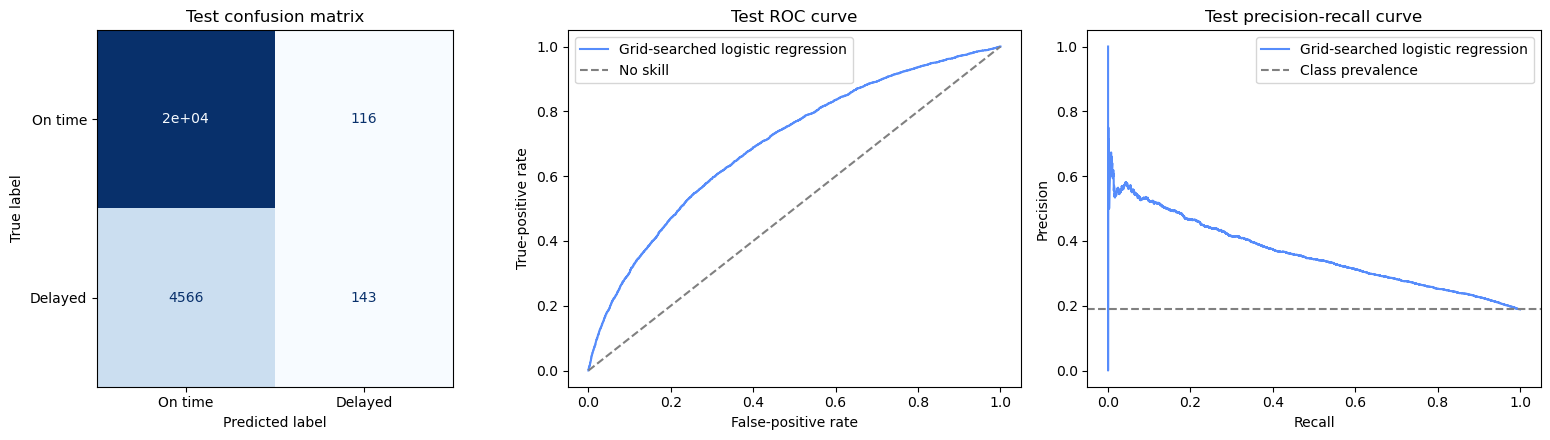

In [10]:
test_predictions = best_logistic_pipeline.predict(X_test)
test_probabilities = best_logistic_pipeline.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_test, test_probabilities)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Test confusion matrix")

axes[1].plot(false_positive_rate, true_positive_rate, label="Grid-searched logistic regression")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Test ROC curve")
axes[1].legend()

axes[2].plot(curve_recall, curve_precision, label="Grid-searched logistic regression")
axes[2].axhline(y_test.mean(), linestyle="--", color="gray", label="Class prevalence")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Test precision-recall curve")
axes[2].legend()

fig.tight_layout()
plt.show()

## Inspect the largest coefficients

The table below inspects the refitted best estimator. Coefficients describe associations in the standardized and one-hot-encoded feature space; they are not causal effects.

In [11]:
feature_names = best_logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficient_series = pd.Series(
    best_logistic_pipeline.named_steps["classifier"].coef_[0],
    index=feature_names,
    name="coefficient",
)

most_positive = coefficient_series.nlargest(10)
most_negative = coefficient_series.nsmallest(10)

coefficient_summary = pd.DataFrame(
    {
        "most_positive_feature": most_positive.index,
        "positive_coefficient": most_positive.values,
        "most_negative_feature": most_negative.index,
        "negative_coefficient": most_negative.values,
    }
)
coefficient_summary

,most_positive_feature,positive_coefficient,most_negative_feature,negative_coefficient
0,categorical__Month_8,0.7072,categorical__Month_11,-0.7611
1,categorical__Month_7,0.6711,categorical__Month_10,-0.5369
2,categorical__Dest_IAH,0.4570,categorical__Reporting_Airline_OH,-0.5353
3,categorical__Dest_DFW,0.4488,categorical__Reporting_Airline_YX,-0.5230
4,categorical__Month_6,0.4304,categorical__Month_3,-0.5004
5,categorical__Dest_HNL,0.3967,categorical__Dest_OAK,-0.3808
6,numeric__CRSDepTime,0.3916,categorical__Month_2,-0.3604
7,categorical__Dest_ORD,0.3908,categorical__Dest_RNO,-0.3553
8,numeric__HourlyRelativeHumidity,0.3111,categorical__Month_1,-0.3276
9,categorical__Dest_BOS,0.2398,categorical__Dest_SAN,-0.3213


## Grid-search interpretation

The cross-validation table explains why the selected hyperparameters won on training data; the held-out test metrics are the primary estimate of generalization. Compare the selected logistic regression with the dummy classifier and the `_01` fixed model rather than judging accuracy in isolation.

The test set must not be used to revise the grid or choose a probability threshold. Threshold selection should use training-only out-of-fold probabilities in a separate experiment. Because this pass uses a random 2019 split, a later phase should use a time-based or later-year evaluation to measure temporal robustness.